# Ptuning
在输入端加入可学习 embedding，但通过 **$\large{MLP}$** 或 **$\large{LSTM}$** 结构生成，不是直接可训练向量。

In [1]:
from datasets import Dataset, load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, DataCollatorForSeq2Seq, TrainingArguments, Trainer

## 加载数据集/tokenizer 以及数据处理

In [2]:
data_path = "/root/autodl-tmp/dataset/alpaca-gpt4-data-zh/alpaca_gpt4_data_zh.json"
ds = load_dataset("json", data_files=data_path, split="train")

path = "model/Qwen3-0.6B"
tokenizer = AutoTokenizer.from_pretrained(path)
print("tokenizer.eos_token is: ", tokenizer.eos_token)

tokenizer.eos_token is:  <|im_end|>


In [3]:
def process_func(example):
    MAX_LENGTH = 256
    input_ids, attention_mask, labels = [], [], []

    instruction = tokenizer(
        "\n".join(["Human: " + example["instruction"], example["input"]]).strip() + "\n\nAssistant: "
    )

    response = tokenizer(example["output"] + tokenizer.eos_token)
    input_ids = instruction["input_ids"] + response["input_ids"]
    attention_mask = instruction["attention_mask"] + response["attention_mask"]
    labels = [-100] * len(instruction["input_ids"]) + response["input_ids"]

    if len(input_ids) > MAX_LENGTH:
        input_ids = input_ids[:MAX_LENGTH]
        attention_mask = attention_mask[:MAX_LENGTH]
        labels = labels[:MAX_LENGTH]
        
    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }
tokenized_ds = ds.map(process_func, remove_columns=ds.column_names)
tokenized_ds, tokenizer.decode(tokenized_ds[1]["input_ids"])

(Dataset({
     features: ['input_ids', 'attention_mask', 'labels'],
     num_rows: 48818
 }),
 'Human: 三原色是什么？\n\nAssistant: 三原色通常指的是红色、绿色和蓝色（RGB）。它们是通过加色混合原理创建色彩的三种基础颜色。在以发光为基础的显示设备中（如电视、计算机显示器、智能手机和平板电脑显示屏）, 三原色可混合产生大量色彩。其中红色和绿色可以混合生成黄色，红色和蓝色可以混合生成品红色，蓝色和绿色可以混合生成青色。当红色、绿色和蓝色按相等比例混合时，可以产生白色或灰色。\n\n此外，在印刷和绘画中，三原色指的是以颜料为基础的红、黄和蓝颜色（RYB）。这三种颜色用以通过减色混合原理来创建色彩。不过，三原色的具体定义并不唯一，不同的颜色系统可能会采用不同的三原色。<|im_end|>')

## 创建模型

In [4]:
model = AutoModelForCausalLM.from_pretrained(path)


---
前置过程还是一样

### step 1 配置文件

In [5]:
from peft import PromptEncoderConfig, TaskType, get_peft_model, PromptEncoderReparameterizationType

config = PromptEncoderConfig(task_type=TaskType.CAUSAL_LM, 
                             num_virtual_tokens=10,
                             encoder_reparameterization_type=PromptEncoderReparameterizationType.MLP,
                             encoder_dropout=0.1, 
                             encoder_num_layers=5, 
                             encoder_hidden_size=512)
config

PromptEncoderConfig(task_type=<TaskType.CAUSAL_LM: 'CAUSAL_LM'>, peft_type=<PeftType.P_TUNING: 'P_TUNING'>, auto_mapping=None, base_model_name_or_path=None, revision=None, inference_mode=False, num_virtual_tokens=10, token_dim=None, num_transformer_submodules=None, num_attention_heads=None, num_layers=None, modules_to_save=None, encoder_reparameterization_type=<PromptEncoderReparameterizationType.MLP: 'MLP'>, encoder_hidden_size=512, encoder_num_layers=5, encoder_dropout=0.1)

### 创建模型配置训练参数

In [6]:
p_model = get_peft_model(model, config)
p_model

/root/miniconda3/lib/python3.12/site-packages/peft/tuners/p_tuning/model.py:105: UserWarning: for MLP, the argument `encoder_num_layers` is ignored. Exactly 2 MLP layers are used.
  warnings.warn(


PeftModelForCausalLM(
  (base_model): Qwen3ForCausalLM(
    (model): Qwen3Model(
      (embed_tokens): Embedding(151936, 1024)
      (layers): ModuleList(
        (0-27): 28 x Qwen3DecoderLayer(
          (self_attn): Qwen3Attention(
            (q_proj): Linear(in_features=1024, out_features=2048, bias=False)
            (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
            (o_proj): Linear(in_features=2048, out_features=1024, bias=False)
            (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
            (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
          )
          (mlp): Qwen3MLP(
            (gate_proj): Linear(in_features=1024, out_features=3072, bias=False)
            (up_proj): Linear(in_features=1024, out_features=3072, bias=False)
            (down_proj): Linear(in_features=3072, out_features=1024, bias=False)
            (act_fn): SiLUActivation()
          )
          (inpu

新增了一个MLP层
```md
(default): PromptEncoder(
      (embedding): Embedding(10, 1024)
      (mlp_head): Sequential(
        (0): Linear(in_features=1024, out_features=512, bias=True)
        (1): ReLU()
        (2): Linear(in_features=512, out_features=512, bias=True)
        (3): ReLU()
        (4): Linear(in_features=512, out_features=1024, bias=True)
      )
)
```

In [7]:
p_model.print_trainable_parameters()

trainable params: 1,323,008 || all params: 597,372,928 || trainable%: 0.2215


In [8]:
hard_args = TrainingArguments(
    output_dir="./chatbot/ptuning",
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    logging_steps=10,
    num_train_epochs=1,
    save_steps=500,
    logging_dir="../tf-logs/ptuning/rus",       
    report_to="tensorboard",            
)

trainer = Trainer(
    model=p_model,
    args=hard_args,
    tokenizer=tokenizer,
    train_dataset=tokenized_ds,
    data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, padding=True),
)

/tmp/ipykernel_8786/2153747018.py:13: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [9]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,2.187500
20,2.093600
30,2.057700
40,2.050500
50,1.976200
60,1.991100
70,1.962700
80,1.967200
90,1.995500
100,2.076800


TrainOutput(global_step=3052, training_loss=1.893851940941217, metrics={'train_runtime': 1485.9574, 'train_samples_per_second': 32.853, 'train_steps_per_second': 2.054, 'total_flos': 3.207508680769536e+16, 'train_loss': 1.893851940941217, 'epoch': 1.0})

In [16]:
from peft import PeftModel

peft_model = PeftModel.from_pretrained(model=model, model_id="./chatbot/ptuning/checkpoint-3052/")
peft_model = peft_model.cuda()

ipt = tokenizer("Human: {}\n{}".format("学习微积分有哪些实用技巧？", "").strip() + "\n\nAssistant: ", return_tensors="pt").to(peft_model.device)
print(tokenizer.decode(peft_model.generate(**ipt, max_length=512, do_sample=True)[0], skip_special_tokens=True))

Human: 学习微积分有哪些实用技巧？

Assistant: 学习微积分是一门非常实用的学科，它在多个领域都有广泛的应用。以下是一些实用的技巧：

1. 每天阅读一本书，每天学习一个概念，可以提高学习效率。

2. 选择适合自己的学习方法，比如自学、线上课程、参加小组学习等，可以根据自己的情况来选择。

3. 建立良好的学习习惯，如每天学习一定时间，预习和复习，及时复习等。

4. 参加在线课程，如Coursera、edX等，可以找到高质量的微积分课程，学习更高效。

5. 学习一些数学基础，如微积分的导数、积分、微分方程等，可以为学习微积分打下坚实的基础。

6. 参加一些数学竞赛，如美国数学奥林匹克竞赛，可以提升学习微积分的能力。

7. 学习微积分的解题技巧，如如何解微分方程，如何计算积分等，可以提高解题能力。

8. 参与数学论坛、数学网站，了解最新的数学知识和解题技巧，可以提高学习效率。

9. 每天复习学习过的知识，及时复习，巩固知识，提高学习效果。

10. 与同学或老师进行讨论，可以加深对知识的理解，提高学习效果。


In [17]:
from peft import PeftModel

peft_model = PeftModel.from_pretrained(model=model, model_id="./chatbot/checkpoint-500/")
peft_model = peft_model.cuda()

ipt = tokenizer("Human: {}\n{}".format("学习微积分有哪些实用技巧？", "").strip() + "\n\nAssistant: ", return_tensors="pt").to(peft_model.device)
print(tokenizer.decode(peft_model.generate(**ipt, max_length=512, do_sample=True)[0], skip_special_tokens=True))

Human: 学习微积分有哪些实用技巧？

Assistant: 1. 从零开始学习微积分。

2. 多练习，特别是应用题。

3. 学习微积分的基础概念，如导数和积分。

4. 学习微分方程。

5. 学习微积分的数学语言，如符号和公式。

6. 学习微积分的几何意义。

7. 学习微积分的应用，如物理和工程。

8. 学习微积分的算法，如数值积分和数值微分。

9. 学习微积分的可视化，如图形和图表。

10. 学习微积分的证明，如微分和积分的定义。

11. 学习微积分的拓扑学，如微分的几何意义。

12. 学习微积分的多元函数和极限。

13. 学习微积分的导数和积分的计算方法。

14. 学习微积分的物理和工程应用。

15. 学习微积分的数学工具，如导数和积分的计算方法。

16. 学习微积分的算法，如数值积分和数值微分。

17. 学习微积分的可视化，如图形和图表。

18. 学习微积分的证明，如微分和积分的定义。

19. 学习微积分的几何意义，如微分的几何意义。

20. 学习微积分的拓扑学，如微分的几何意义。


收敛更快

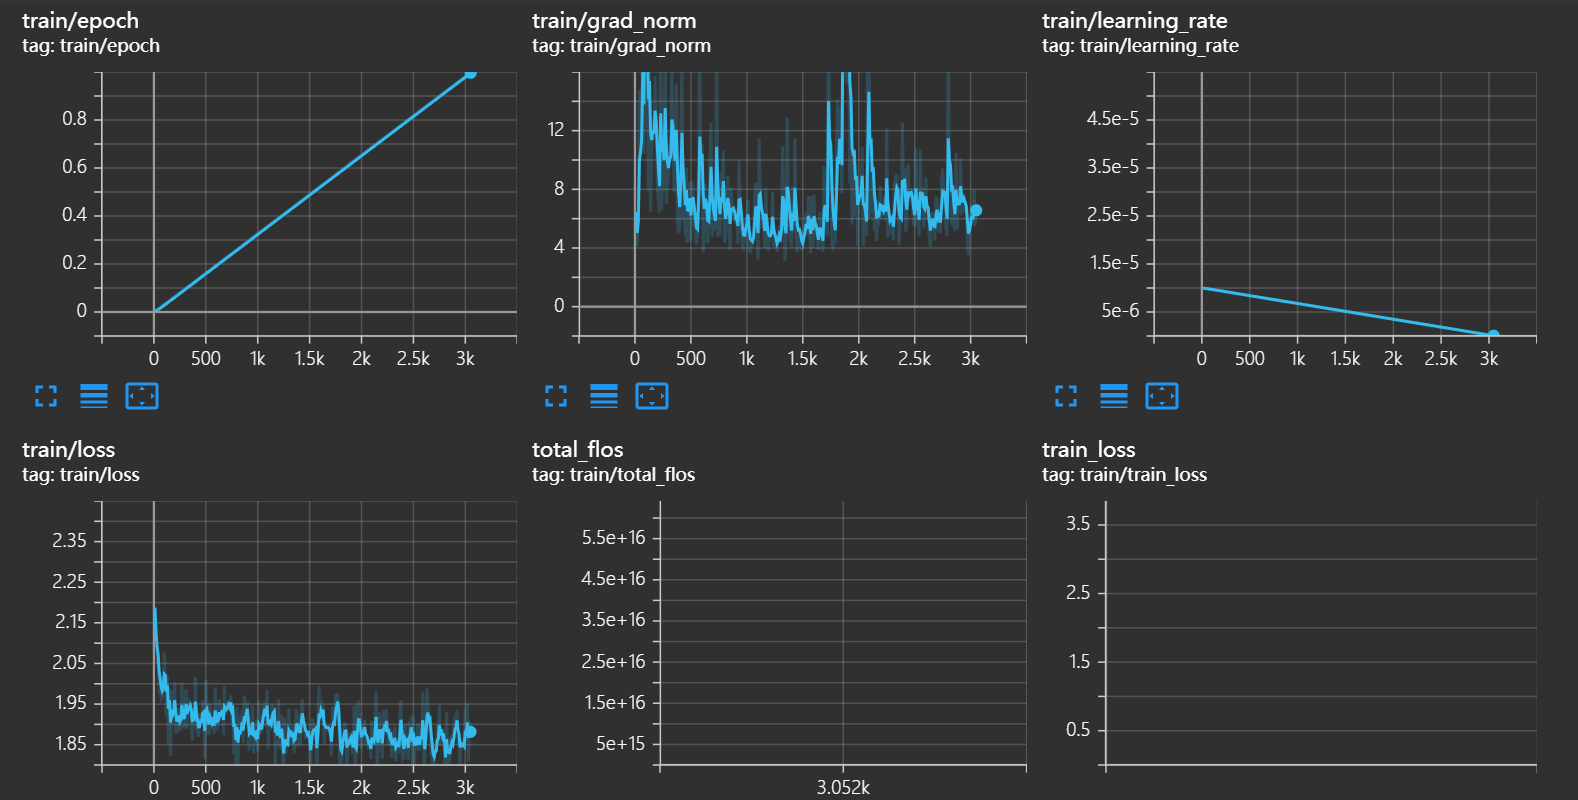